### Formulation of the problem:

#### Variables, Sets, Data:
- $x_{i,j} \in \{0,1\}$ if brick $i$ is assigned to SR $j$
- $d_{i,j}$ = distance between brick $i$ and SR $j$ (data)
- $v_i$ = workload for brick $i$ (value between 0 and 1) (data)
- $S$ = set of SRs
- $B$ = set of bricks $(1, 2, 3, \ldots)$

#### Constraints (30 in total):

$\sum_{i \in B} x_{i,1} \cdot v_i \leq 1.2$

$\sum_{i \in B} x_{i,2} \cdot v_i \leq 1.2$

$\sum_{i \in B} x_{i,3} \cdot v_i \leq 1.2$

$\sum_{i \in B} x_{i,4} \cdot v_i \leq 1.2$

$\sum_{i \in B} x_{i,1} \cdot v_i \geq 0.8$

$\sum_{i \in B} x_{i,2} \cdot v_i \geq 0.8$

$\sum_{i \in B} x_{i,3} \cdot v_i \geq 0.8$

$\sum_{i \in B} x_{i,4} \cdot v_i \geq 0.8$

22 times this constraints for each brick i:

$\sum_{j \in S} x_{1,j} = 1$ (example with i=1)

#### Objective Function:

$$\min \sum_{i \in B} \sum_{j \in S} d_{i,j} \cdot x_{i,j}$$

$$\min \sum_{i \in B} \sum_{j \in S} \left({x'}_{i,j} - 2{x'}_{i,j} \cdot x_{i,j} + x_{i,j}\right)$$

In [1]:
# pip install gurobipy

In [2]:
import gurobipy
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
import numpy as np

## Data

In [3]:
num_bricks = 22

###### --- Data ---
distances = [[16.16, 24.08, 24.32, 21.12], 
     [19, 26.47, 27.24, 17.33], 
     [25.29, 32.49, 33.42, 12.25], 
     [0, 7.93, 8.31, 36.12], 
     [3.07, 6.44, 7.56, 37.37], 
     [1.22, 7.51, 8.19, 36.29], 
     [2.80, 10.31, 10.95, 33.5], 
     [2.87, 5.07, 5.67, 38.8], 
     [3.8, 8.01, 7.41, 38.16], 
     [12.35, 4.52, 4.35, 48.27], 
     [11.11, 3.48, 2.97, 47.14], 
     [21.99, 22.02, 24.07, 39.86], 
     [8.82, 3.3, 5.36, 43.31], 
     [7.93, 0, 2.07, 43.75], 
     [9.34, 2.25, 1.11, 45.43], 
     [8.31, 2.07, 0, 44.43], 
     [7.31, 2.44, 1.11, 43.43], 
     [7.55, 0.75, 1.53, 43.52], 
     [11.13, 18.41, 19.26, 25.4], 
     [17.49, 23.44, 24.76, 23.21], 
     [11.03, 18.93, 19.28, 25.43], 
     [36.12, 43.75, 44.43, 0]] 

workloads = [0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
     0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
     0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
     0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
     0.1698, 0.2531]

## Initial state : 
SR1_center = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SR2_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
SR4_center = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

SR1_initial_state = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
SR2_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
SR3_initial_state = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0]
SR4_initial_state = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]
# --- Print the initial state with workloads ---

# SR1: [1,8,9], workload = 1.08
# Total distance = xx

# --- Print the initial state with workloads and distances ---

print("Initial state:\n")
SRs = [SR1_initial_state, SR2_initial_state, SR3_initial_state, SR4_initial_state]
for i, SR in enumerate(SRs):
     bricks = [j+1 for j in range(num_bricks) if SR[j] == 1]
     workload = sum([workloads[j] for j in range(num_bricks) if SR[j] == 1])
     print(f"SR{i+1}: {bricks} , Workload = {workload:.2f}")
     per_sr_dist = [
     sum(distances[j][i] for j in range(num_bricks) if SRs[i][j] == 1)
     for i in range(4)
     ]
     total_distance = sum(per_sr_dist)
print(f"\nTotal distance = {total_distance:.2f}")
          
     


Initial state:

SR1: [4, 5, 6, 7, 8, 15] , Workload = 0.95
SR2: [10, 11, 12, 13, 14] , Workload = 1.34
SR3: [9, 16, 17, 18] , Workload = 0.70
SR4: [1, 2, 3, 19, 20, 21, 22] , Workload = 1.01

Total distance = 187.41


## First objective function : minimization Distance

In [4]:
model = Model("Bricks_and_Sales_Reps")


###### --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")


##### --- Constraints ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR4")

# 1 brick per SR
for i in range(num_bricks):
    model.addConstr( SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i]   == 1, name=f"brick_{i+1}_assignment")
## 

# --- Objective function 2 : Minimize the disruption ---
model.setObjective( sum(distances[i][0]*SR_1[i] + distances[i][1]*SR_2[i] + distances[i][2]*SR_3[i] + distances[i][3]*SR_4[i]for i in range(num_bricks) ),GRB.MINIMIZE)



# --- Resolve the optimization problem ---
model.Params.OutputFlag = 0
model.optimize()

Restricted license - for non-production use only - expires 2026-11-23


In [5]:
if model.status == GRB.OPTIMAL:
    print( "Find Optimal solution !")
    print( f"Minimal Distance Cost = {model.objVal:.2f}\n")

    # --- Afficher la répartition des briques ---
    for j, (SR, name) in enumerate(
        [(SR_1, "SR_1"), (SR_2, "SR_2"), (SR_3, "SR_3"), (SR_4, "SR_4")],
        start=1
    ):
        print(f"{name} :")
        total_load = sum(SR[i].x * workloads[i] for i in range(num_bricks))
        assigned = [i + 1 for i in range(num_bricks) if SR[i].x > 0.5]

        print(f"  - Assigned bricks : {assigned}")
        print(f"  - Total load     : {total_load:.3f}\n")
    
    # afficher nombre de disruptions
    disruptions = 0
    for i in range(num_bricks):
        if (SR_1[i].x > 0.5 and SR1_initial_state[i] == 0) or \
           (SR_2[i].x > 0.5 and SR2_initial_state[i] == 0) or \
           (SR_3[i].x > 0.5 and SR3_initial_state[i] == 0) or \
           (SR_4[i].x > 0.5 and SR4_initial_state[i] == 0):
            disruptions += 1

    print(f"Number of disruptions: {disruptions}")

else:
    print(f" No optimal solution (status = {model.status})")

Find Optimal solution !
Minimal Distance Cost = 154.60

SR_1 :
  - Assigned bricks : [4, 5, 6, 7, 8, 9, 12, 19, 20]
  - Total load     : 1.038

SR_2 :
  - Assigned bricks : [11, 13, 14, 18]
  - Total load     : 1.045

SR_3 :
  - Assigned bricks : [10, 15, 16, 17]
  - Total load     : 1.115

SR_4 :
  - Assigned bricks : [1, 2, 3, 21, 22]
  - Total load     : 0.803

Number of disruptions: 7


## Second objective function : minimize the Disruption

In [6]:
model = Model("Bricks_and_Sales_Reps")

###### --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")


##### --- Constraints ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR4")

# 1 brick per SR
for i in range(num_bricks):
    model.addConstr( SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i]   == 1, name=f"brick_{i+1}_assignment")
## 

# --- Objective function 2 : Minimize the disruption ---
model.setObjective( sum(SR1_initial_state[i] - 2 * SR1_initial_state[i]*SR_1[i]+ SR_1[i] +
                        SR2_initial_state[i] - 2 * SR2_initial_state[i]*SR_2[i]+ SR_2[i] +
                        SR3_initial_state[i] - 2 * SR3_initial_state[i]*SR_3[i]+ SR_3[i] +
                        SR4_initial_state[i] - 2 * SR4_initial_state[i]*SR_4[i]+ SR_4[i] 
                        for i in range(num_bricks) ),GRB.MINIMIZE)



# --- Resolve the optimization problem ---
model.Params.OutputFlag = 0
model.optimize()

In [7]:
if model.status == GRB.OPTIMAL:
    print( "Find Optimal solution !")
    print( f"Minimal Disruption Cost = {model.objVal:.2f}\n")

    # --- Afficher la répartition des briques ---
    for j, (SR, name) in enumerate(
        [(SR_1, "SR_1"), (SR_2, "SR_2"), (SR_3, "SR_3"), (SR_4, "SR_4")],
        start=1
    ):
        print(f"{name} :")
        total_load = sum(SR[i].x * workloads[i] for i in range(num_bricks))
        assigned = [i + 1 for i in range(num_bricks) if SR[i].x > 0.5]

        print(f"  - Assigned bricks : {assigned}")
        print(f"  - Total load     : {total_load:.3f}\n")

else:
    print(f" No optimal solution (status = {model.status})")

Find Optimal solution !
Minimal Disruption Cost = 2.00

SR_1 :
  - Assigned bricks : [4, 5, 6, 7, 8, 15]
  - Total load     : 0.951

SR_2 :
  - Assigned bricks : [11, 12, 13, 14]
  - Total load     : 1.085

SR_3 :
  - Assigned bricks : [9, 10, 16, 17, 18]
  - Total load     : 0.958

SR_4 :
  - Assigned bricks : [1, 2, 3, 19, 20, 21, 22]
  - Total load     : 1.007



### Epsilon method [0.8, 1.2]

ε =  1  →   minimal distance = 187.24
ε =  2  →   minimal distance = 172.84
ε =  3  →   minimal distance = 167.25
ε =  4  →   minimal distance = 161.00
ε =  5  →   minimal distance = 155.41
ε =  6  →   minimal distance = 154.63
ε =  7  →   minimal distance = 154.60
ε =  8  →   minimal distance = 154.60
ε =  9  →   minimal distance = 154.60
ε = 10  →   minimal distance = 154.60
ε = 11  →   minimal distance = 154.60
ε = 12  →   minimal distance = 154.60
ε = 13  →   minimal distance = 154.60
ε = 14  →   minimal distance = 154.60
ε = 15  →   minimal distance = 154.60
ε = 16  →   minimal distance = 154.60
ε = 17  →   minimal distance = 154.60
ε = 18  →   minimal distance = 154.60
ε = 19  →   minimal distance = 154.60
ε = 20  →   minimal distance = 154.60
ε = 21  →   minimal distance = 154.60
ε = 22  →   minimal distance = 154.60


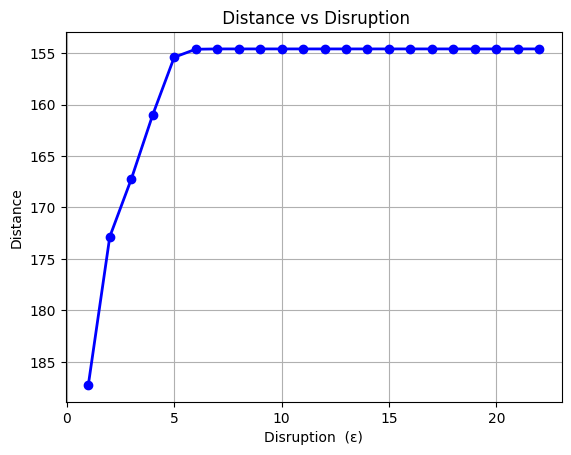

In [8]:
# --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")

# --- Contraintes workloads ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name="min_workload_SR4")
    

# --- Une seule affectation par brique ---
for i in range(num_bricks):
    model.addConstr(SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] == 1, name=f"brick_{i+1}_assignment")

# --- Objective 1 : total distance ---
distance_expr = sum(
    distances[i][0] * SR_1[i] +
    distances[i][1] * SR_2[i] +
    distances[i][2] * SR_3[i] +
    distances[i][3] * SR_4[i]
    for i in range(num_bricks)
)

# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
    SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
    SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
    SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i])/2
    for i in range(num_bricks)
)

# --- Initial objective (for first solve) ---
model.setObjective(distance_expr, GRB.MINIMIZE)

# --- Loop epsilon-constraint ---
pareto_points = []
epsilons = [0,1,2,3,4,5, 6,7,8,9, 10,11, 12,13,14 ,15,16,17, 18, 19, 20, 21, 22]

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    model.setObjective(distance_expr, GRB.MINIMIZE)
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →   minimal distance = {model.objVal:.2f}")

    model.remove(constr)
    model.update()

# --- Visualisation  ---
if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()


### Epsilon methode [0.85, 1.15]

ε =  1  →   minimal distance = 187.24
ε =  2  →   minimal distance = 172.97
ε =  3  →   minimal distance = 172.19
ε =  4  →   minimal distance = 169.13
ε =  5  →   minimal distance = 160.35
ε =  6  →   minimal distance = 160.32
ε =  7  →   minimal distance = 160.32
ε =  8  →   minimal distance = 160.32
ε =  9  →   minimal distance = 160.32
ε = 10  →   minimal distance = 160.32
ε = 11  →   minimal distance = 160.32
ε = 12  →   minimal distance = 160.32
ε = 13  →   minimal distance = 160.32
ε = 14  →   minimal distance = 160.32
ε = 15  →   minimal distance = 160.32
ε = 16  →   minimal distance = 160.32
ε = 17  →   minimal distance = 160.32
ε = 18  →   minimal distance = 160.32
ε = 19  →   minimal distance = 160.32
ε = 20  →   minimal distance = 160.32
ε = 21  →   minimal distance = 160.32
ε = 22  →   minimal distance = 160.32


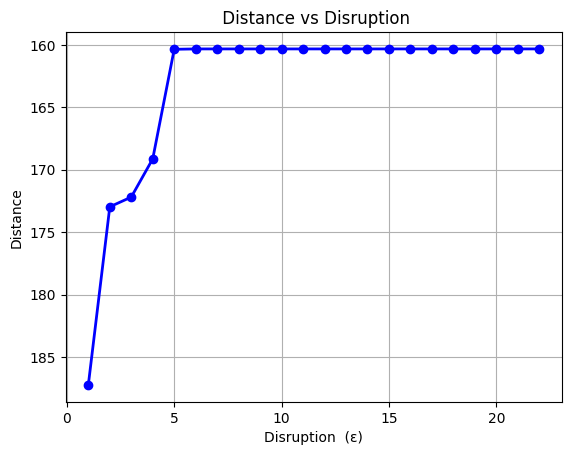

In [9]:
# --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")

# --- Contraintes workloads ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.15, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.85, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.15, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.85, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.15, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.85, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.15, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.85, name="min_workload_SR4")
    

# --- Une seule affectation par brique ---
for i in range(num_bricks):
    model.addConstr(SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] == 1, name=f"brick_{i+1}_assignment")

# --- Objective 1 : total distance ---
distance_expr = sum(
    distances[i][0] * SR_1[i] +
    distances[i][1] * SR_2[i] +
    distances[i][2] * SR_3[i] +
    distances[i][3] * SR_4[i]
    for i in range(num_bricks)
)

# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
    SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
    SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
    SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i])/2
    for i in range(num_bricks)
)

# --- Initial objective (for first solve) ---
model.setObjective(distance_expr, GRB.MINIMIZE)

# --- Loop epsilon-constraint ---
pareto_points = []
epsilons = [0,1,2,3,4,5, 6,7,8,9, 10,11, 12,13,14 ,15,16,17, 18, 19, 20, 21, 22]

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    model.setObjective(distance_expr, GRB.MINIMIZE)
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →   minimal distance = {model.objVal:.2f}")

    model.remove(constr)
    model.update()

# --- Visualisation  ---
if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()


### Epsilon methode [0.9, 1.1]

ε =  1  →   minimal distance = 187.24
ε =  2  →   minimal distance = 172.97
ε =  3  →   minimal distance = 172.46
ε =  4  →   minimal distance = 171.68
ε =  5  →   minimal distance = 167.33
ε =  6  →   minimal distance = 162.43
ε =  7  →   minimal distance = 162.43
ε =  8  →   minimal distance = 162.43
ε =  9  →   minimal distance = 162.43
ε = 10  →   minimal distance = 162.43
ε = 11  →   minimal distance = 162.43
ε = 12  →   minimal distance = 162.43
ε = 13  →   minimal distance = 162.43
ε = 14  →   minimal distance = 162.43
ε = 15  →   minimal distance = 162.43
ε = 16  →   minimal distance = 162.43
ε = 17  →   minimal distance = 162.43
ε = 18  →   minimal distance = 162.43
ε = 19  →   minimal distance = 162.43
ε = 20  →   minimal distance = 162.43
ε = 21  →   minimal distance = 162.43
ε = 22  →   minimal distance = 162.43


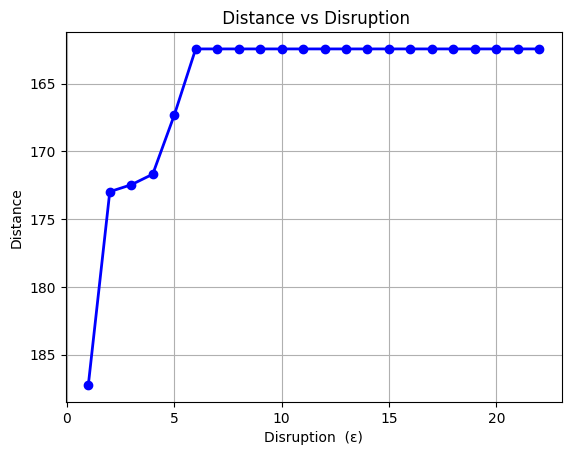

In [10]:
# --- Variables ---
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")

# --- Contraintes workloads ---
# SR1  workloads
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) <= 1.1, name="max_workload_SR1")
model.addConstr(sum(SR_1[i] * workloads[i] for i in range(num_bricks)) >= 0.9, name="min_workload_SR1")

# SR2
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) <= 1.1, name="max_workload_SR2")
model.addConstr(sum(SR_2[i] * workloads[i] for i in range(num_bricks)) >= 0.9, name="min_workload_SR2")

# SR3
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) <= 1.1, name="max_workload_SR3")
model.addConstr(sum(SR_3[i] * workloads[i] for i in range(num_bricks)) >= 0.9, name="min_workload_SR3")

# SR4
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) <= 1.1, name="max_workload_SR4")
model.addConstr(sum(SR_4[i] * workloads[i] for i in range(num_bricks)) >= 0.9, name="min_workload_SR4")
    

# --- Une seule affectation par brique ---
for i in range(num_bricks):
    model.addConstr(SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] == 1, name=f"brick_{i+1}_assignment")

# --- Objective 1 : total distance ---
distance_expr = sum(
    distances[i][0] * SR_1[i] +
    distances[i][1] * SR_2[i] +
    distances[i][2] * SR_3[i] +
    distances[i][3] * SR_4[i]
    for i in range(num_bricks)
)

# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
    SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
    SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
    SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i])/2
    for i in range(num_bricks)
)

# --- Initial objective (for first solve) ---
model.setObjective(distance_expr, GRB.MINIMIZE)

# --- Loop epsilon-constraint ---
pareto_points = []
epsilons = [0,1,2,3,4,5, 6,7,8,9, 10,11, 12,13,14 ,15,16,17, 18, 19, 20, 21, 22]

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    model.setObjective(distance_expr, GRB.MINIMIZE)
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →   minimal distance = {model.objVal:.2f}")

    model.remove(constr)
    model.update()

# --- Visualisation  ---
if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()


### Checking how our model scales up with the instance with 10 SRs and 100 zones

ε =  3  →  minimal distance = 189.412
ε =  5  →  minimal distance = 181.515
ε =  7  →  minimal distance = 174.591
ε =  9  →  minimal distance = 167.789
ε = 10  →  minimal distance = 164.493
ε = 12  →  minimal distance = 157.934
ε = 14  →  minimal distance = 151.565
ε = 15  →  minimal distance = 148.550
ε = 17  →  minimal distance = 142.336
ε = 22  →  minimal distance = 129.475
ε = 24  →  minimal distance = 125.398
ε = 30  →  minimal distance = 115.037
ε = 34  →  minimal distance = 109.175
ε = 40  →  minimal distance = 101.119
ε = 50  →  minimal distance = 89.666
ε = 60  →  minimal distance = 79.635
ε = 70  →  minimal distance = 73.045
ε = 80  →  minimal distance = 70.938
ε = 85  →  minimal distance = 70.790
ε = 87  →  minimal distance = 70.790
ε = 89  →  minimal distance = 70.790
ε = 90  →  minimal distance = 70.790
ε = 92  →  minimal distance = 70.790
ε = 93  →  minimal distance = 70.790
ε = 94  →  minimal distance = 70.790
ε = 95  →  minimal distance = 70.790
ε = 97  →  minimal dista

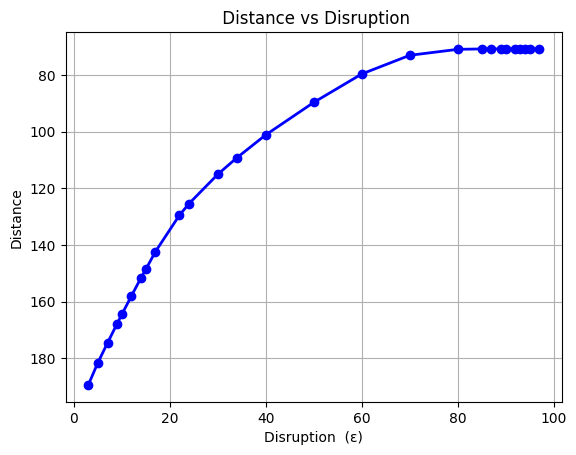

In [13]:
model = Model("Bricks_and_Sales_Reps_100")

Bricks = 100
Sales = 10
### Creat data 
#Randome Workloads 100 
workloads = np.random.rand(Bricks)
# sum workloads = 10
workloads = workloads/sum(workloads)*Sales

#Randome distance 100 
np.random.seed(12)
x_Brics = np.random.rand(Bricks)**2 *4
np.random.seed(10)
Y_Brics  = np.random.rand(Bricks)**2 *4
#Implementation of Distance Matrix with center for each SR
Distance = np.array([ np.sqrt((x_Brics[:] - x_Brics[i])**2 + (Y_Brics[:] - Y_Brics[i])**2) for i in range(Sales) ])

#Creat an initial state that takes into account the center of each SR
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)

for i in range(Bricks):
    j = i % Sales
    SR_initial_state[j,i] = 1

#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.BINARY, name="SR_10")

## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
    
## Constraints Bricks
for i in range(Bricks):
    model.addConstr( sum(SR_10[j,i] for j in range(Sales))    == 1, name=f"brick_{i+1}_assignment")


# --- Objective 1 : total distance ---
distance_expr = ( sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
)
)


# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i] )/2
    for i in range(Bricks) for j in range(Sales)
)



# --- Epsilon-constraint loop ---
epsilons = [0, 2, 3, 5, 7, 9, 10, 12, 14, 15, 17, 22, 24, 30, 34, 40,50, 60, 70, 80, 85, 87, 89, 90, 92, 93, 94, 95, 97]
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    
    model.setObjective(distance_expr, GRB.MINIMIZE)
    
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →  minimal distance = {model.objVal:.3f}")
        
    #Delate old constraints
    model.remove(constr)
    model.update()

# print("\nPareto points (ε, distance):")
# for p in pareto_points:
#     print(p)

if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()

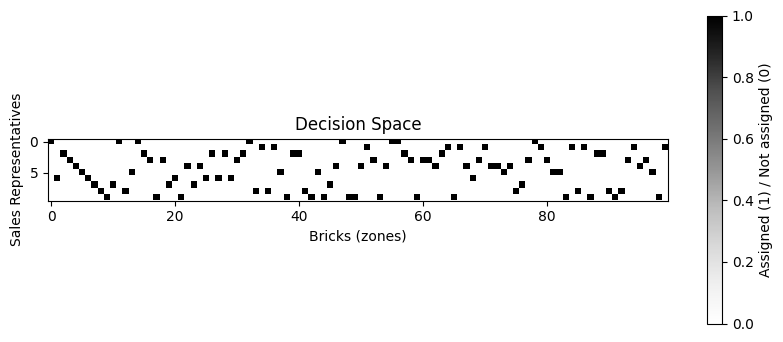

In [12]:
model.optimize()

assign = np.zeros((Sales, Bricks))
for j in range(Sales):
    for i in range(Bricks):
        assign[j, i] = SR_10[j, i].X  

plt.figure(figsize=(10, 4))
plt.imshow(assign, cmap="Greys", interpolation="nearest")
plt.xlabel("Bricks (zones)")
plt.ylabel("Sales Representatives")
plt.title("Decision Space")
plt.colorbar(label="Assigned (1) / Not assigned (0)")
plt.show()